✅ Ambiente configurado com sucesso!
📤 Faça o upload do arquivo 'IMDBmovies.xlsx'


Saving IMDBmovies.xlsx (1).xlsx to IMDBmovies.xlsx (1).xlsx

✅ Arquivo 'IMDBmovies.xlsx (1).xlsx' detectado e carregado com sucesso!
📊 Total de registros: 47


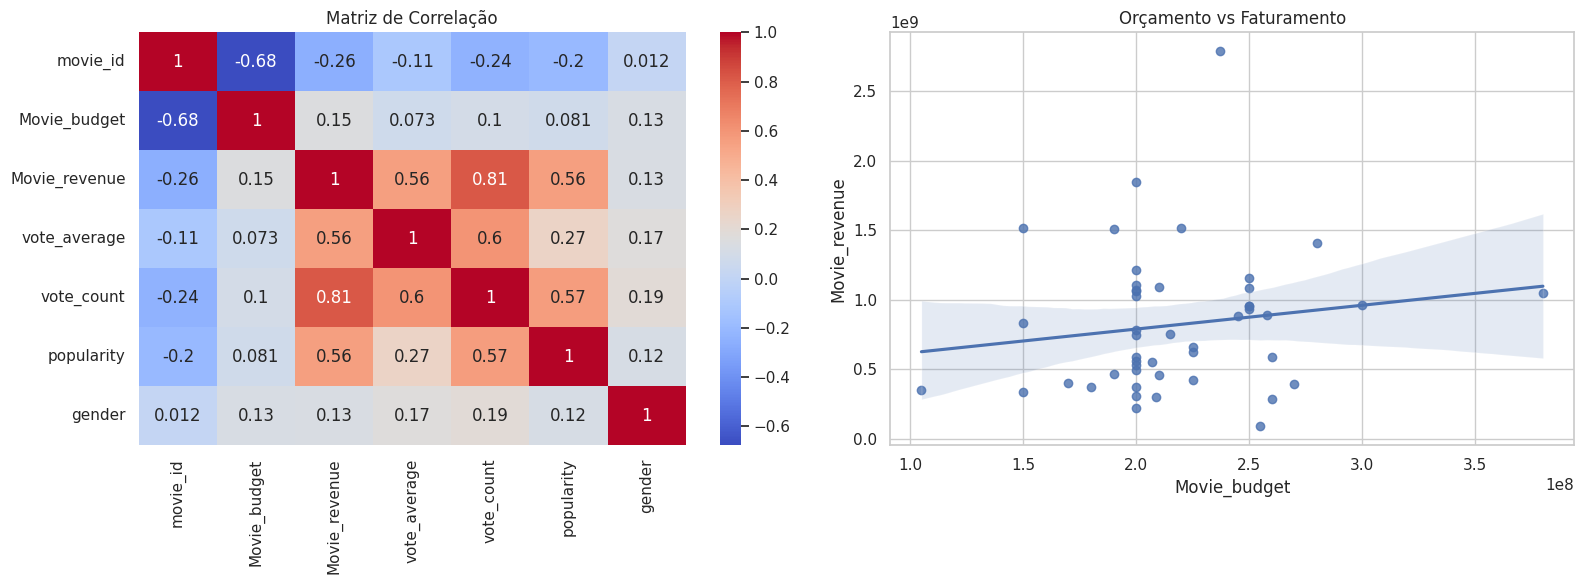


--- RESULTADOS ---
Regressão Linear R²: 0.3637
Random Forest R²:    0.5635


In [ ]:
# ============================================
# PROJETO DE IA: PREDIÇÃO DE FATURAMENTO DE FILMES
# Disciplina: ICD/ADS
# Dataset: IMDBmovies.xlsx
# ============================================

# Célula 1 - Configuração
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import io
import os
from google.colab import files

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Ambiente configurado com sucesso!")

# Célula 2 - Upload e carregamento
print("📤 Faça o upload do arquivo 'IMDBmovies.xlsx'")
uploaded = files.upload()

# Busca automática pelo arquivo correto
file_name = None
for name in uploaded.keys():
    if 'IMDBmovies' in name and (name.endswith('.xlsx') or name.endswith('.xls')):
        file_name = name
        break

if file_name:
    df = pd.read_excel(io.BytesIO(uploaded[file_name]))
    print(f"\n✅ Arquivo '{file_name}' detectado e carregado com sucesso!")
    print(f"📊 Total de registros: {df.shape[0]}")
else:
    print("\n❌ ERRO: Arquivo 'IMDBmovies.xlsx' não encontrado.")

df.head()

# Célula 3 - Análise Exploratória
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Matriz de Correlação')

sns.regplot(data=df, x='Movie_budget', y='Movie_revenue', ax=axes[1])
axes[1].set_title('Orçamento vs Faturamento')

plt.tight_layout()
plt.show()

# Célula 4 - Modelagem
features = ['Movie_budget', 'vote_average', 'vote_count', 'popularity']
X = df[features]
y = df['Movie_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Experimento 1: Regressão Linear
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
p_lr = lr.predict(X_test_scaled)

# Experimento 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
p_rf = rf.predict(X_test)

print("\n--- RESULTADOS ---")
print(f"Regressão Linear R²: {r2_score(y_test, p_lr):.4f}")
print(f"Random Forest R²:    {r2_score(y_test, p_rf):.4f}")